### Install scanpy for preprocessing and leidenalg for clustering

In [1]:
# !pip3 install scanpy
# !pip3 install leidenalg

Alternatively, you may can download using conda:

In [2]:
# !conda install -c conda-forge scanpy 

## 1. Import libraries and explore Anndata

Import `scanpy`, `numpy`, and `pandas`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import scanpy as sc

Data is made available using the `datasets.pbmc3k()` function and loads into adata, referring to the **annotated dataframe** structure used to handle the data. Data, post-alignment and gene annotation, is fashioned into a "feature" or "count" matrix of dimensions `num_observations` x `num_variables`.`num_observations` corresponds to individual cells with their unique barcodes while `num_variables` corresponds to annotated genes. Metadata collected from point of sample acquisition (patient ID, disease state, tissue biopsy location) are collected and paired with the raw count data matrix in the Anndata format, visualized below:

Anndata stores a matrix `X` surrounded by pandas DFs which saves cell barcodes and gene annotations. Different transformed or logged matrices of raw data can be saved in `layers` of `X`. Calculations (multiplicative scaling) or low-dimensional data projectsion (PCA/UMAPed data) can also be saved in `obsp` or `varp`. Any other unstructured data annotations (you initials, data access data, GEO number) can be stored in the unstructured `uns`. The rest of the tutorial skips the intricacies of Anndata and will focus on extracting meaning from the `X` counts matrix. For a detailed introduction to Anndata manipulation, see https://www.sc-best-practices.org/introduction/analysis_tools.html. 

In [2]:
# Load data, this should take ~5 seconds.
adata = sc.datasets.pbmc3k() 

Here we have count data representing 32738 genes in 2700 PBMCs. You can call the `adata` object to further explore this data structure.

Genes that are most widely expressed are listed below. Interestingly, these are mostly ribosomal (gene.startswith('RP') or housekeeping genes rather than T-cell specific genes. This is expected given that ribosomal RNA is highly abundant in the cell and housekeeping genes are constitutively expressed since they are required for basic cell function.

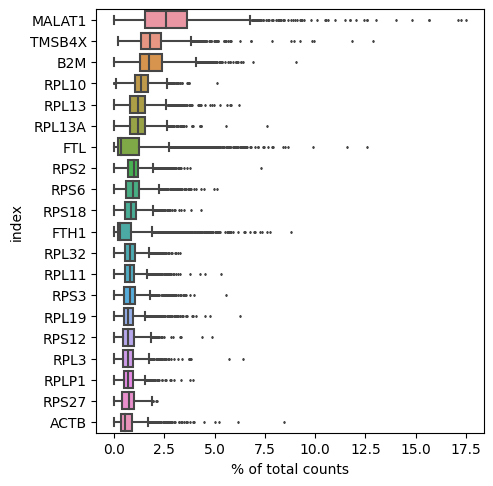

In [3]:
sc.pl.highest_expr_genes(adata, n_top=20, )

## 2. Filter low quality reads

Dead cells will have ruptured cell membranes, leading to a low overall mRNA count due to leakage. We will filter these cells out. Additionally, genes foudn in fewer than 2-3 cells are filtered to reduce computational overhead and filter cells for which noise may be an issue:

In [4]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

##### Filter cells with high number mitochondrial reads

Dataset quality is important for downstream analysis. Low quality reads can arise from dead cells that have lysed and contain only remnants of mitochondrial RNA. These cells will have a high percentage of mitochondrial-annotated genes and may have a low count depth for genes of interest. Here, we'll filter out cells for which mitochondrial reads are transcriptionally overrepresented.  Other QC methods not featured in this tutorial include doublet elimination, ambient RNA detection, and ribosomal RNA regression.

In [5]:
# generate new metadata 'var' that show all genes starting with MT- , aka our mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-') 

# calcaultes the precentage of all reads that are mitochondrial reads.
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

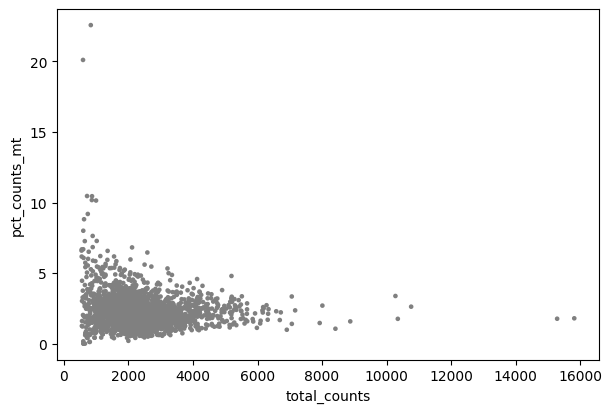

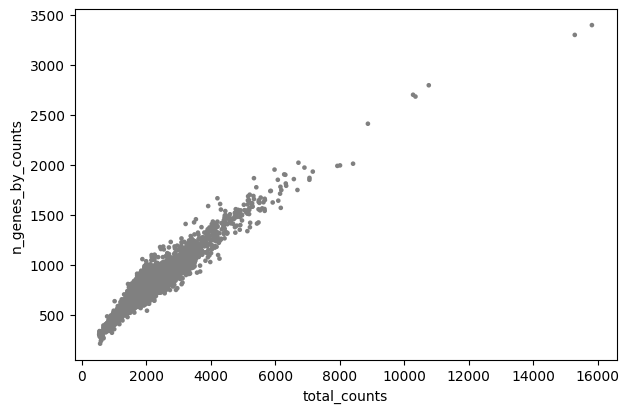

In [6]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [7]:
# filter out cells based on mitochondrial read percentage of greater than 5%
adata = adata[adata.obs.pct_counts_mt < 5, :]

Filter out cells where total gene content is high as these represent possible doublets. Note that some labs do not recommend doublet removal in this fashion anymore because high count-cells might be biologically valuable/real. More sophisticated methods like Scrublet (https://github.com/swolock/scrublet) and scDblFinder (https://bioconductor.org/packages/release/bioc/html/scDblFinder.html) are now available.

In [8]:
# Roughly filter out doublets with the sledge hammer thresholding method
adata = adata[adata.obs.n_genes_by_counts < 2500, :]

## 3. Normalize and scale reads for downstream expression analysis

We will normalize counts to 10000 sequencing reads per cell to allow for downstream between-cell comparisons. That is, we are making the assumption that all cells should produce roughly the same number of transcripts. With similar cell types this might be a safe assumption, but in other situations you may want to normalize by library size instead. Next, we will log scale the data. 

In [9]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

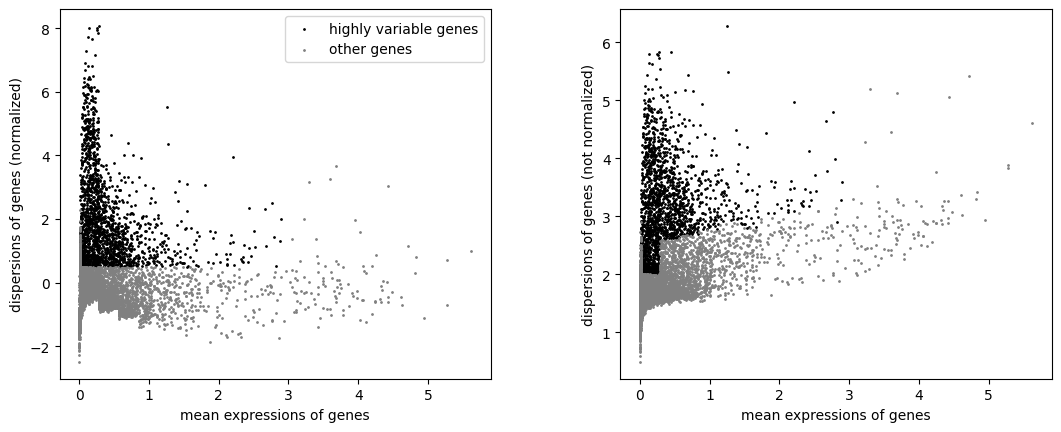

In [10]:
# take a look at the normalized v unnormalized data: 
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)

## 4. Save your work and pre-PCA steps

Save the raw normalized/scaled data for downstream differential expression analysis and gene expression visualization. This will maintain the original state of the Anndata object while we select a set of highly variable genes from which to base our dimensionality reductions. This helps to reduce computational overhead, though with a dataset this small it is of minor importance.

In [11]:
# Save raw expression values before variable gene subset
adata.raw = adata

# find highly variable genes in the dataset (calculated above) and subset the data
adata = adata[:, adata.var.highly_variable]

# regress out the effects of total RNA counts and the <5% mitochondrial reads in case this impacts our data
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

We will scale our data to unit variance before principal components analysis is performed.

In [12]:
sc.pp.scale(adata, max_value=10)

## 5. Principal component analysis and UMAP visualizations

We will reveal the low dimensional embedding spaces along which the data varies the most. This will enable higher fidelity clustering and cell-type annotations.

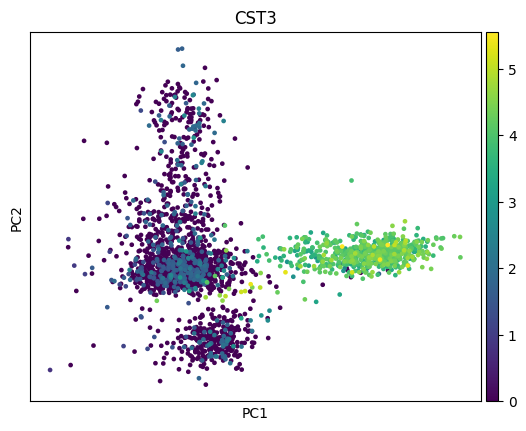

In [13]:
# perform PCA using partial singular value decomposition algorithm ARPACK
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca(adata, color=['CST3'])

You can view the relative importance of each PC in dataset below. Can you ballpark how many major cell types are in the dataet based off of the PC1/2 graph and the elbow plot below?

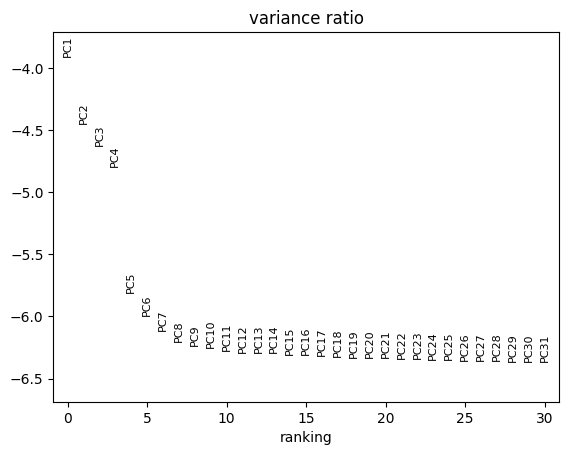

In [14]:
sc.pl.pca_variance_ratio(adata, log=True)

## 6. Compute neighborhood graph and visualize UMAP

We'll visualize cell clusters with UMAP projections.

In [18]:
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)

In [19]:
sc.tl.umap(adata)

## 7. Manual identification of cell types

Cell type identification post-dimensionality reduction is an important step in identifying rare cell types, cell types of interest, or overall organism/sub-community state. Here, we will annotate cell types by canonical cell-surface markers used by immunologists, available at https://www.celltypist.org/encyclopedia/Immune/v2/. Common PBMC cell types include T cells, B cells, monocytes, natural killer cells, dendritic cells. We will also explore rarer megakaryocytes.

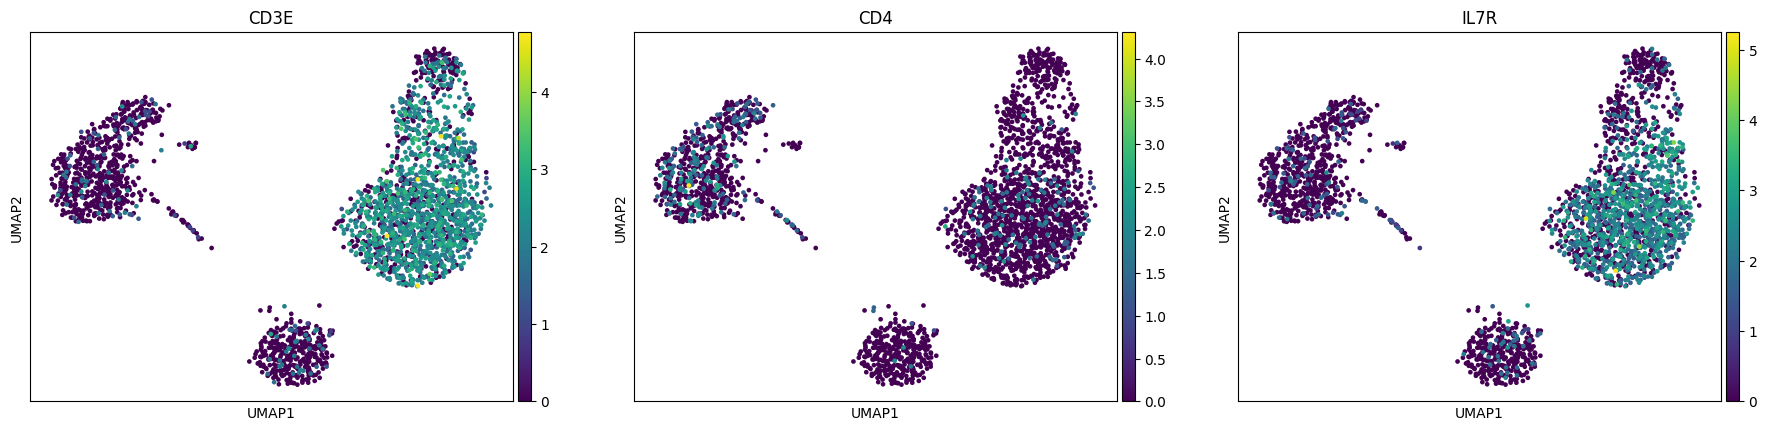

In [20]:
# CD4 cells
sc.pl.umap(adata, color=['CD3E', 'CD4', 'IL7R'], ncols = 3)

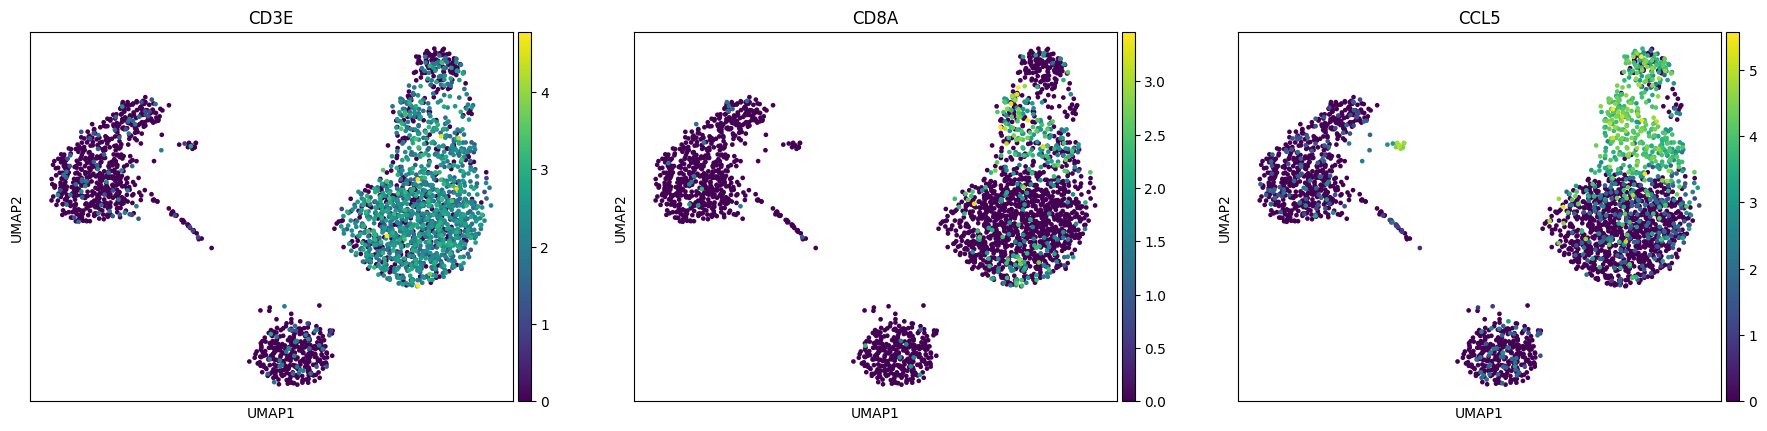

In [21]:
# CD8 cells
sc.pl.umap(adata, color=['CD3E', 'CD8A', 'CCL5'], ncols = 3)

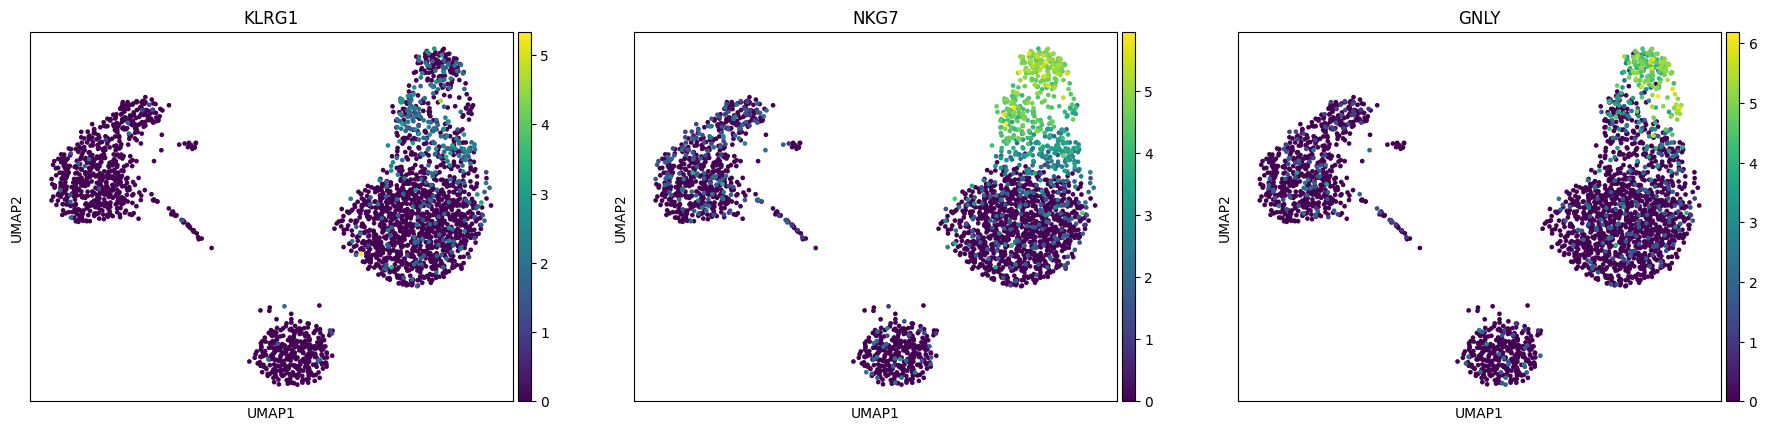

In [22]:
# NKs
sc.pl.umap(adata, color=['KLRG1', 'NKG7', 'GNLY'], ncols = 3)

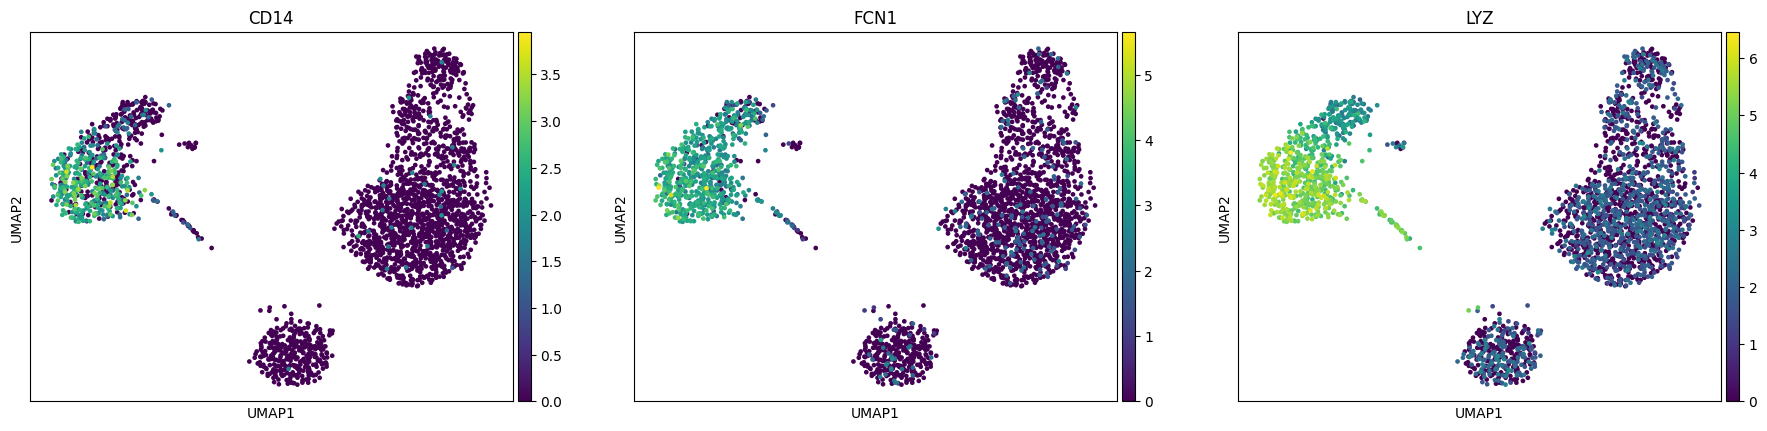

In [23]:
# CD14+ monocytes
sc.pl.umap(adata, color=['CD14', 'FCN1', 'LYZ'], ncols = 3)

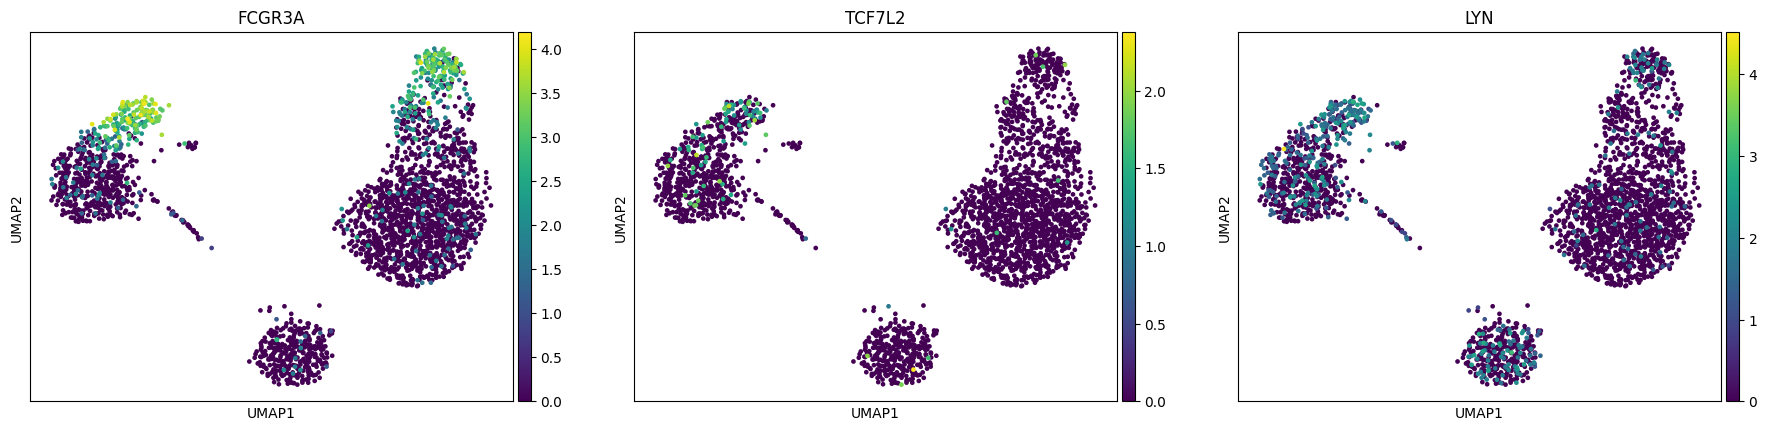

In [24]:
# CD16+ monocytes
sc.pl.umap(adata, color=['FCGR3A', 'TCF7L2', 'LYN'], ncols = 3)

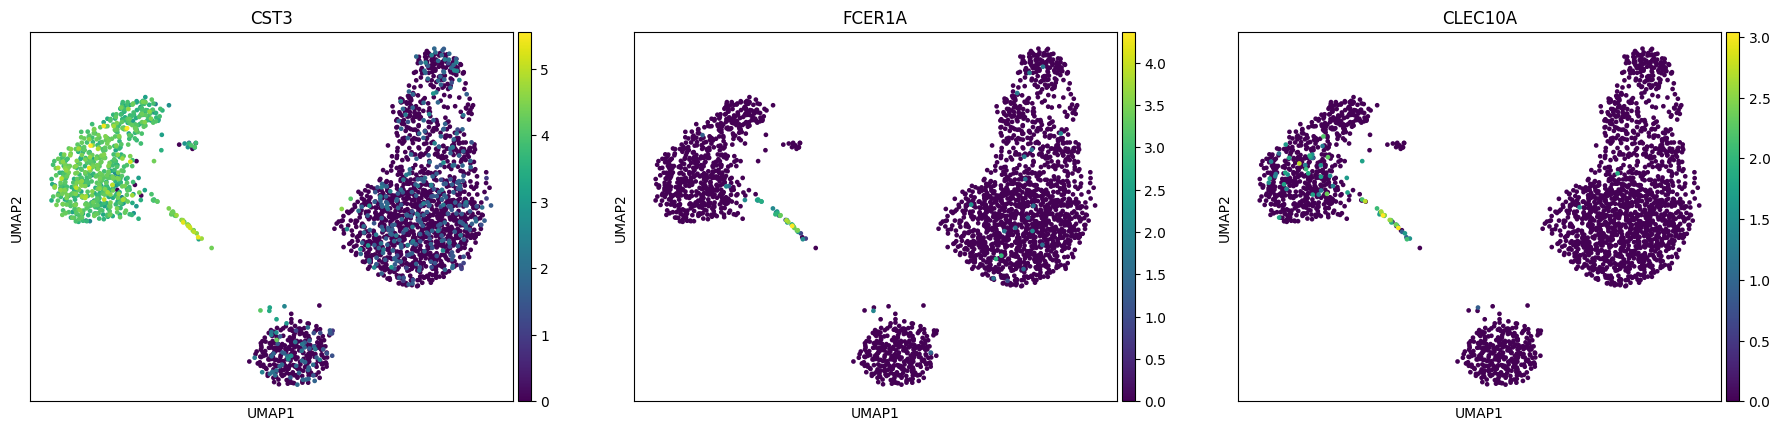

In [25]:
# Dendritic cells, professional antigen presenters
sc.pl.umap(adata, color=['CST3', 'FCER1A', 'CLEC10A'], ncols = 3)

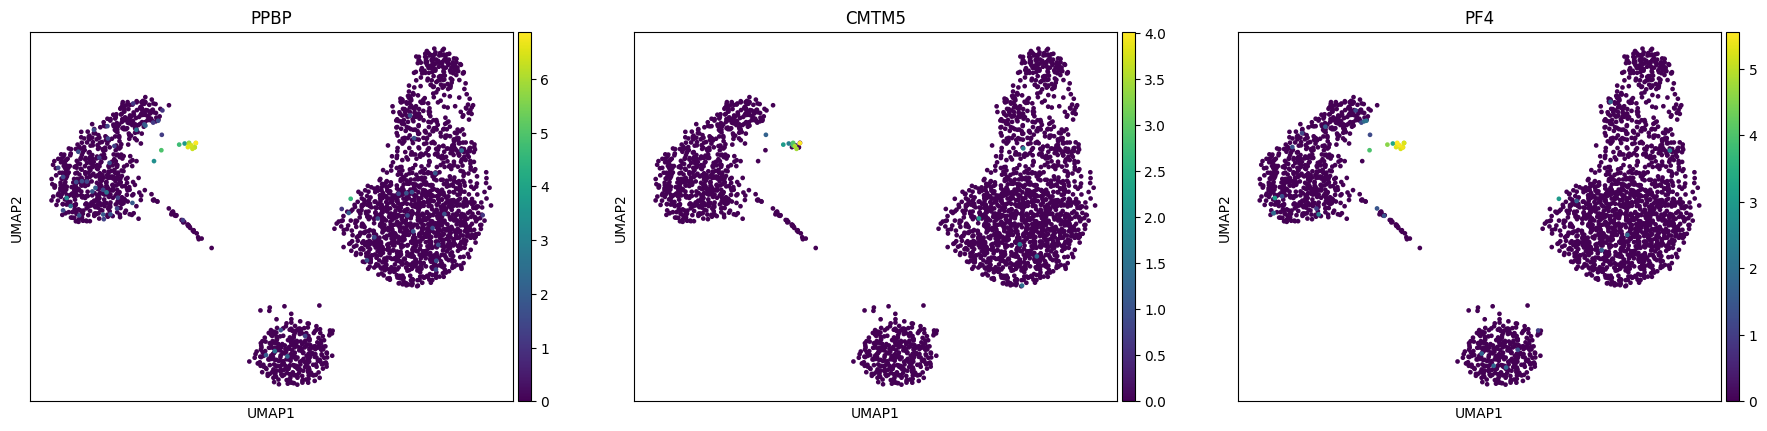

In [26]:
# Megakaryocytes/Platelets
sc.pl.umap(adata, color=['PPBP', 'CMTM5', 'PF4'], ncols = 3)

## 8. Cluster assignment

Now that we have explored well-known canonical PBMC cell type markers, lets assign cell clusters.

We will detect cell clusters using community detection methods outlined by Traag *et al*. in https://arxiv.org/abs/1810.08473. We use the Leiden K-nearest neighbor graph algorithm to find a partition that optimally assigns cell type. Image courtesy of community RNAseq book (https://www.sc-best-practices.org/cellular_structure/clustering.html).

![KNN Leiden](https://www.sc-best-practices.org/_images/clustering.jpeg)

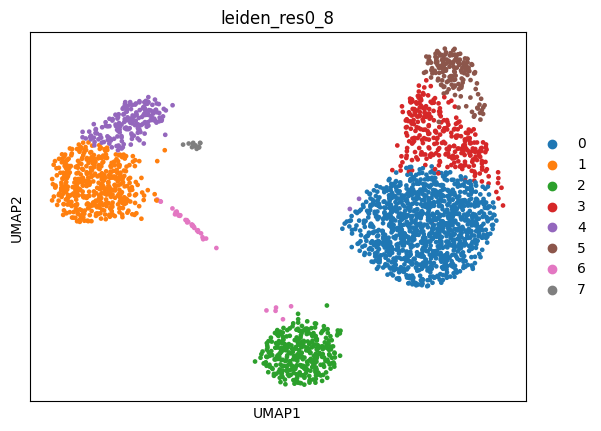

In [35]:
sc.tl.leiden(adata, key_added="leiden_res0_8", resolution=0.9)
sc.pl.umap(adata, color='leiden_res0_8', ncols = 2)

Now that we have clusters, we can annotate them based off of the expression of canonical genes as explored above.

In [36]:
new_cluster_names = [
    'CD4 T', 'CD14+ Monocytes',
    'B', 'CD8 T',
    'CD16+ Monocytes', 'NK',
    'Dendritic Cells', 'Megakaryocytes']
adata.rename_categories('leiden_res0_8', new_cluster_names)

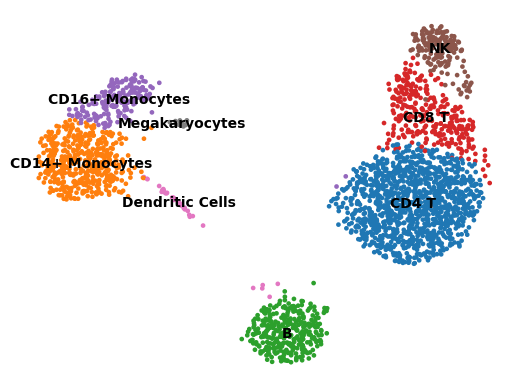

In [37]:
sc.pl.umap(adata, color='leiden_res0_8', legend_loc='on data', title='', frameon=False)

We can now rank highly differentially expressed genes in each cluster to try to identify which cell types they represent.

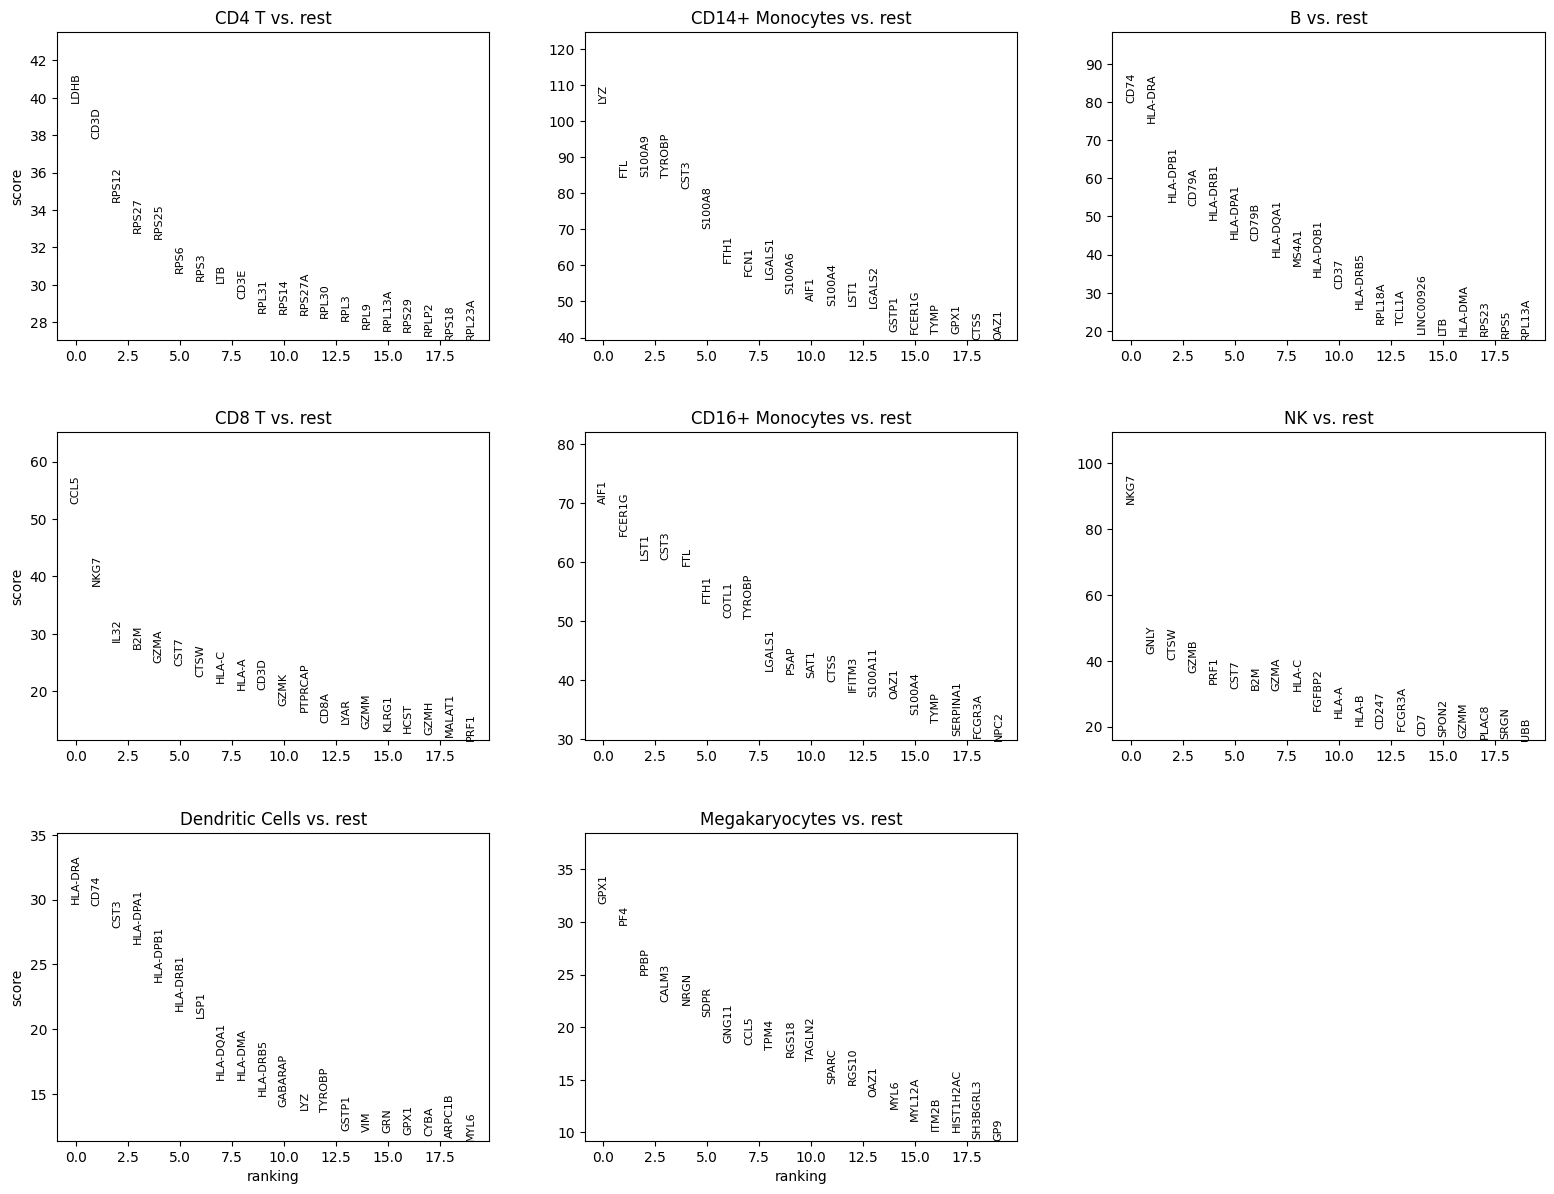

In [38]:
sc.tl.rank_genes_groups(adata, 'leiden_res0_8', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False, ncols = 3)

##### More resources: 

For more on supervised/automated clustering and cell marker annotation methods, see https://www.nature.com/articles/s41467-022-28803-w.